<div align="right" style="text-align: right"><i>Peter Norvig<br>Dec 2018<br>Updated Jun 2020</i></div>

# Portmantout Words

A [***portmanteau***](https://en.wikipedia.org/wiki/Portmanteau) is a word that squishes together two words, like  ***mathlete*** = ***math*** + ***athlete***.  Inspired by [**Darius Bacon**](http://wry.me/), I covered this as a programming exercise in my 2012 [**Udacity course**](https://www.udacity.com/course/design-of-computer-programs--cs212). In 2018 I was re-inspired by [**Tom Murphy VII**](http://tom7.org/), who added a new twist:  [***portmantout words***](http://www.cs.cmu.edu/~tom7/portmantout/) ([***tout***](https://www.duolingo.com/dictionary/French/tout/fd4dc453d9be9f32b7efe838ebc87599) from the French for *all*).


Informally, **portmantout** means that you take all the words in a set and mush them together in some order such that each word overlaps the next. Or more formally: 

A **portmantout** of a set of words *W* is a string *S* constructed as follows:
- Make a path *P* that is an ordered list containing all the words in *W* at least once each.
- Every word in *P* (except the first) must *overlap*: it must begin with a prefix that is the same as a suffix of the previous word.
- The string *S* is formed by concatenating the letters in *P*, but using each overlap only once, not twice.
- For example:
  - Word set: *W* = {world, hello, lowbrow}
  - Path: *P* = [hel<u>lo</u>, <u>lo</u>wbro<u>w</u>, <u>w</u>orld]
  - String: *S* = "hellowbroworld".


This notebook develops a program that can find a portmantout *S* for a set *W* of over 100,000 words in a few seconds. The program attempts to minimize the length of *S*, but does not guarantee that it is the shortest possible. Along the way it generated these interesting portmanteaux:


- **impromptutankhamenability** [impromptu, tutankhamen, amenability]: willingness to see the Egyptian exhibit on the spur of the moment.
- **preferendumdums** [prefer, referendum, dumdums]: agreeable  uninformed voters.
- **dashikimonogrammarianarchy** [dashiki, kimono, monogram, grammarian, anarchy]: the chaos that ensues when a linguist gets involved in choosing how to enscribe African/Japanese garb.
- **fortyphonshore** [forty, typhons, onshore]: a dire weather report. 
- **allegestionstage** [alleges, egestions, onstage]: a brutal theatre critique.
- **skymanipulablearsplittingler** [skyman, manipulable, blears, earsplitting, tinglers]: a nerve-damaging aviator.
- **edinburgherselflesslylyricize** [edinburgh, burghers, herself, selflessly, slyly, lyricize]: a Scottish music review.


# Overall Design

I originally thought I would define a major function, `portman`, to generate the portmantout string *S* from the set of words *W*, and a minor function, `is_portman`, to verify the result:

    portman(W: Wordset) -> str              # Compute the string S from the set of words W
    is_portman(S: str, W: Wordset) -> bool  # Verify that S is a valid portmantout covering W

But then I realized that verification would be difficult. For example,  *S* =  `'helloworld'` would be rejected as non-overlapping if parsed as `'hello'` + `'world'`, but accepted if parsed as `'hello'` + `'low'` + `'world'`. It was hard for `is_portman` to decide which parse was intended, which is a shame because `portman` *knew* which was intended. 

To make everything explicit (and more efficient), each **step** in the path will consist of a word and an integer that specifies the number of characters in the overlap with the previous word, for example:

     [Step(0, 'hello'), Step(2, 'low'), Step(1, 'world')]

With that in mind, I decided on the following calling and [naming](https://en.wikipedia.org/wiki/Natalie_Portman) conventions:

    natalie(W: Wordset) -> Path             # Find a portmantout path P for a set of words W
    portman(P: Path) -> str                 # Compute the string S represented by the path P
    is_portman(P: Path, W: Wordset) -> bool # Verify that P is a valid path covering W

Thus I can generate a portmantout string *S* with:

    S = portman(natalie(W))

# Basic Data Types and functions

Here I describe how to implement the main data types in Python:

- **Word**: a `str`.
- **Wordset**: a  `set` of words.
- **Step**: a named tuple of the overlap (the length of the prefix that matches the previous word's suffix) and a word. 
- **Path**: a `list` of steps.


In [1]:
from collections import defaultdict, Counter, namedtuple
from typing import Iterable

Step         = namedtuple('Step', ('overlap', 'word'))
type Word    = str
type Path    = list[Step]
type Wordset = set[Word]

Here are the functions `portman` and `is_portman`:

In [2]:
def portman(P: Path) -> Word:
    """Compute the portmantout string S from the path P."""
    # Concatenate the non-overlapping part of each step
    return ''.join(step.word[step.overlap:] for step in P)

def is_portman(P: Path, W: Wordset) -> bool:
    """Is the Path P a portmantout of the Wordset W?"""
    S = portman(P)
    return (all(word in S for word in W) and         # 1. Every word in W is a substring of S
            all(step.overlap > 0 for step in P[1:])) # 2. Every word (except first) overlaps

# TODO: natalie

# *W0*: A Tiny Wordset

A tiny example wordset `W0`, path `P0`, and string `S0`:

In [3]:
W0 = {'anarchy', 'dashiki', 'grammarian', 'kimono', 'monogram',
      'a', 'am', 'an', 'arc', 'arch', 'aria', 'as', 'ash', 'dash', 'gram', 
      'grammar', 'i', 'mar', 'maria', 'mono', 'narc', 'no', 'on', 'ram'}

P0 = [Step(0, 'dashiki'),
      Step(2,      'kimono'),
      Step(4,        'monogram'),
      Step(4,            'grammarian'),
      Step(2,                    'anarchy')]

assert is_portman(P0, W0)

S0 = portman(P0)
S0

'dashikimonogrammarianarchy'

# Steps in a Path

My intuition is that finding a shortest *S* is an NP-hard problem, and with 100,000 words to cover, it is unlikely that I can find a guaranteed shortest possible string in a reasonable amount of time. A common approach to NP-hard problems is a **greedy algorithm**: make the locally best choice at each step, without ever undoing a step, in the hope that the steps will fit together into a solution that is not too far from the best solution. I distinguish two types of steps:

- **Unused word step**: uses a word that is in *W*, has not been used in the path yet, and has a prefix that matches the suffix of the previous word.
- **Bridging word step**: if no unused word step is possible, we need to do something to get back on track. I call that something a **bridge**: a step that repeats a previously-used word in order to provide a new suffix that will allow us to place an unused word on the next step. 

At each turn I will choose the step that minimizes the number of *excess letters** added to the path. That is, minimie the number of letters that a step adds, relative to a baseline model in which all the words are concatenated with no repeated words and no overlap between them. (That's not a valid solution, but it is useful as a benchmark.) So if a step adds an unused word, and it overlaps with the previous word by three letters, that is an excess of -3: I've saved three letters over just concatenating the unused word. (Note that a negative excess is a positive thing!) For a bridging word step, the excess is the number of letters that do not overlap either the previous word or the next word. So all unused word steps have negative excess and all bridging steps are non-negative. Therefore if there is an unused word step, we don't need to consider a bridging step.

**Examples:** In each row of the table below, `'ajar'` is the previous word,  but each row makes different assumptions about what unused words remain, and thus we get different choices for the step to take. The table shows the overlapping letters between the previous word and the step, and in the case of bridges, it shows the   unused word that the step is bridging to. (Sometimes we need a bridge that is two words long, but with our word set *W* we will never need more than that.) The final column shows the excess letter score (and the actual excess letters).

|Previous|Step(s)|Overlap|Bridge to|Type of Step(s)|Excess|
|--------|----|----|---|---|---|
| ajar|**jarring**|jar|–|*unused word* |-3| 
| ajar|**arbitrary**|ar|–|*unused word* |-2|
| ajar|**rabbits**|r|–|*unused word*|-1|
| ajar|**argot**|ar|goths|*one-step bridge* |0|
| ajar|**arrow**|ar|owlets| *one-step bridge*|1 (r)|
| ajar|r**ani, iraq**|r|quizzed| *two-step bridge*|5 (anira) | 

W2 = Wordset('ajar jarring ringlet letter terminal alto'.split())

Let's go over the examples:
- **jarring**: Here we assume `jarring` is an unused word. It overlaps with `ajar` by 3 letters, giving it an excess cost of -3.
- **arbitrary** and **rabbits**: unused words that overlap by fewer than 3 letters, so would only be chosen if there were no unused words with more overlap.
- **argot** and **arrow**: One-step bridges; a bridge with the least excess would be chosen.
- **rani, iraq**: a two-step bridge. Suppose `quizzed` is the only remaining unused word. There is no single word that bridges from any suffix of `ajar` to any prefix of `quizzed`. But `rani` can bridge from `'r'` to `'i'` and `iraq` can bridge from `'i'` to `'q'`. This two-word bridge has an excess score of 5 due to the letters `anira` not overlapping anything.

# Redefining Wordset for Efficiency

With an 108,000 word word set, the program will be slow if we have to consider every possible word on very step. Here are some things we want to be able to do efficiently, and some questions to answer?
- Decide which words in *W* have been used in the path so far and which are unused.
- Quickly find an unused word that matches a suffix of the previous word in the path.
- Failing that, quickly find a good bridge.
- Can we eliminate some of the 108,000 words from consideration?
- Can we prove that we will never get stuck in a dead end?

To answer these questions I will redefine `Wordset` and `Path` so that they do some precomputation when they are constructed, caching information that will help make the choice of each step more efficient. We'll start with the `Wordset`:

- We can eliminate from consideration all words that are **subwords** of other words. For example, given that the word 'scampi' is in our word list, we have to put it into the path at some point. But when we do, we've also automatically added the words 'a', 'am', 'amp', 'camp', 'campi', 'i', 'scam', and 'scamp'. So we can divide our words into two sets and store them as the `.subwords` and `.nonsubwords` attributes of the Wordset. When we start constructing a path we will know that we only have to cover the `.nonsubwords`.
- Bridges should use **short words**. We don't need to consider `antidisestablishmentarianism` as a possible bridge word. We'll precompute a list of short words that are good candidates for bridges and store them on the `.short_words` attribute. (I arbitrarily set the limit at five letters, except that if the first or last letter is a rare letter for that position, they don't count. So a short word could be up to 7 letters.)
- A bridge may be used multiple times in the construction of a path. It makes sense to precompute all the reasonable bridges and store them under the `.bridges` attribue. We'll describe how to build bridges later.

In [4]:
class Wordset(set[Word]):
    """A set of words, with cached data structures for efficieency."""
    def __init__(self, words):
        W = self
        W.update(words)
        W.subwords    = {part for w in W for part in subparts(w) if part in W}
        W.nonsubwords = W - W.subwords
        W.short_words = {w for w in W if is_short_word(w)}
        W.bridges     = build_bridges(W)

def subparts(word: Word) -> set[str]:
    """All non-empty proper substrings of word."""
    return {word[i:j] 
            for i in range(len(word)) 
            for j in range(i + 1, len(word) + int(i != 0))} # don't use word[0:len(word) + 1]

def is_short_word(word: Word, maxlen=5, rare_start='jkqxyz', rare_end='qxfwzubvopikh') -> bool: 
    """Is this a short word, suitable for use in bridges?"""
    # Short words are a maximmum of 5 letters, except we don't count rare first or last letters
    limit = maxlen + int(word[0] in rare_start) + int(word[-1] in rare_end)
    return len(word) <= limit
    
# TODO: build_bridges

# Redefining Path for Efficiency

While building a path, we want to keep track of what words need to be added to the path, and we want to be able to quickly find words that have a prefix matching the previous step's suffix. So we will pre-compute two attributes on a path:

- The `.unused_words` attribute holds the nonsubwords in *W* that have not yet been added to the path.
- The `.unused_startswith` attribute is a dict that maps from each possible word prefix to a set of the remaining unused words that start with that prefix.
  - Example entry: `P.unused_startswith['somet'] == {'something', 'sometimes'}`.
- These data structures are updated on each step. When `'dirt'` is added to the path, we remove it from `.unused_words` and also remove it from the `'d'`, `'di'`, and `'dir'` entries in `.unused_startswith`.


In [5]:
class Path(list[Step]):
    """A list of steps, with cached data structures for efficiency."""
    def __init__(self, steps, W: Wordset):
        self.unused_words = W.nonsubwords.copy()
        self.unused_startswith = startswith_table(self.unused_words)
        for step in steps:
            self.add_step(step)

    def add_step(self, step: Step) -> None:
        """Add step to path; remove step's word from `.unused_words` 
        and from `.unused_startswith[pre]` for each prefix `pre`."""
        self.append(step)
        word = step.word
        if word in self.unused_words: # Maintain .unused_words and .unused_startswith
            self.unused_words.remove(word)
            for pre in prefixes(word):
                self.unused_startswith[pre].remove(word)
                if not self.unused_startswith[pre]: # clean up unused key
                    del self.unused_startswith[pre]

In [6]:
def prefixes(word: Word) -> list[str]:
    """All non-empty proper prefixes of word."""
    return [word[:i] for i in range(1, len(word))]

def startswith_table(words) -> dict[str, set[Word]]: 
    """A dict mapping a prefix to all the words it starts:
    {'somet': {'something', 'sometimes'}, ...}."""
    return multimap((pre, w) for w in words for pre in prefixes(w)) 

def multimap(pairs) -> dict[object, set]:
    """Given (key, val) pairs, make a dict of {key: {val,...}}."""
    result = defaultdict(set)
    for key, val in pairs:
        result[key].add(val)
    return result

# Building Bridges

Recall that we want `W.bridges[suf][pre]` to be the minimal-excess bridge between a suffix of the previous word and a prefix of an unused nonsubword in *W*. The words in the bridge can be subwords or nonsubwords, as long as they are short words. Example bridges:

      W.bridges['ar']['c']  == Bridge(excess=0, [Step(2, 'arc')])
      W.bridges['ar']['ow'] == Bridge(excess=1, [Step(2, 'arrow')])
      W.bridges['r']['q']   == Bridge(excess=5, [Step(1, 'rani'), Step(1, 'iraq')])
      
To build **one-word bridges**, consider every short word, and split it up in all possible ways into a prefix that will overlap the previous word, a suffix that will overlap the next word, and a count of zero or more excess letters in the middle that don't overlap anything. Suggest all these bridges, but for each suffix/prefix pair we only keep the bridge that have the minimal excess.

Here's an example of splitting the word 'arrow' into pieces that might overlap the previous and next word; the middle number is the excess of the bridge:

In [7]:
def splits(word: Word) -> list[tuple[str, int, str]]: 
    """Ways to split up word, as a list of (prefix, excess, suffix) tuples."""
    return [(word[:i], excess, word[i+excess:])
            for excess in range(len(word) - 1)
            for i in range(1, len(word) - excess)]

In [8]:
splits('arrow')

[('a', 0, 'rrow'),
 ('ar', 0, 'row'),
 ('arr', 0, 'ow'),
 ('arro', 0, 'w'),
 ('a', 1, 'row'),
 ('ar', 1, 'ow'),
 ('arr', 1, 'w'),
 ('a', 2, 'ow'),
 ('ar', 2, 'w'),
 ('a', 3, 'w')]

We will also need **two-word bridges**. With only one-word bridges, the algorithm can get stuck in a dead end where there is no bridge from a suffix of the previous word to an unused word. But if we add in too many  two-word bridges the algorithm would be slow, bogged down with all those bridges to check. Thus, I decided to only use two-word bridges that bridge from a single last letter in the previous word to a single first letter in a following word. If we can construct a bridge from every single letter suffix to every single letter prefix, then we know the algorithm can never get stuck. 

In [9]:
Bridge  = namedtuple('Bridge', 'excess, steps')

type Bridges = dict[str, dict[str, Bridge]] # bridges[prefix][suffix] = Bridge(...)

def build_bridges(W: Wordset):
    """A table of bridges[pre][suf] == Bridge(excess, steps),
    where each bridge is the minimal-excess bridge formable from W.short_words."""
    short_startswith = startswith_table(W.short_words)
    bridges          = defaultdict(dict)
    # One-word bridges: consider every way to split up every short word into suffix/excess/prefix
    for word in W.short_words:
        for (pre, excess, suf) in splits(word):
            suggest_bridge(bridges, word, pre, excess, suf)
    # Two-word bridges: only bridge from a single letter to a single letter
    for word1 in W.short_words:
        for suf in suffixes(word1): 
            for word2 in short_startswith[suf]: 
                excess = len(word1) + len(word2) - len(suf) - 2
                A, B = word1[0], word2[-1] # First and last letters
                step2 = Step(len(suf), word2)
                suggest_bridge(bridges, word1, A, excess, B, step2)
    return bridges

def suggest_bridge(bridges: Bridges, word: Word, pre: str, excess: int, suf: str, step2=None):
    """Store a new bridge if it has less excess than any previous bridges[pre][suf]."""
    if suf != pre and (suf not in bridges[pre] or excess < bridges[pre][suf].excess):
        steps = [Step(len(pre), word)]
        if step2: steps.append(step2)
        bridges[pre][suf] = Bridge(excess, steps)

def suffixes(word: Word) -> list[str]:
    """All non-empty proper suffixes of word, in longest first order."""
    return [word[i:] for i in range(1, len(word))]

# natalie: Portmantout Pathmaker

The function `natalie` does a greedy search for a portmantout path. As stated above, the approach is to start with a path of one word (either given as an optional argument or chosen arbitrarily from the nonsubwords in *W*), and then repeatedly add steps, each step coming from either `unused_word_step` or  `bridging_steps`. Since the function `unused_word_step` will return zero or one step, and `bridging_steps` will return one or two steps; I decided the simplest interface is to have them both return a list of steps.

`unused_word_step` considers every suffix of the previous word, where the function `suffixes` is guaranteed to order the longest suffixes first. If a suffix starts an unused words, we choose it. Since we're going longest-suffix first, no other word choice could do better on the excess letters metric.

If there is no `unused_word_step` that works for the previous word, we try the function `bridging_steps`, which considers every suffix of the previous word, and for each one it looks in the `W.bridges[suf]` table to see what prefixes `pre` we can bridge to from this suffix. It collects all the bridges `W.bridges[suf][pre]` where `pre` starts some currently unused word. Finally, out of all the possible bridges, it chooses the one with minimal excess cost.

In [10]:
def natalie(W: Wordset, start=None) -> Path:
    """Return a portmantout path containing all words in W. You can optionally give the start word."""
    first_step = Step(0, start or first(W.nonsubwords))
    P = Path([first_step], W)
    while P.unused_words:
        steps = unused_word_step(P) or bridging_steps(W, P)
        for step in steps:
            P.add_step(step)
    return P

def unused_word_step(P: Path) -> list[Step]:
    """Return [Step(overlap, unused_word)] or []."""
    prev_word = P[-1].word
    for suffix in suffixes(prev_word):
        if suffix in P.unused_startswith and (unused_word := first(P.unused_startswith[suffix])):
            return [Step(len(suffix), unused_word)]
    return []

def bridging_steps(W: Wordset, P: Path) -> list[Step]:
    """The steps from the minimal-excess bridge that bridges 
    from a suffix of the previous word to a prefix of any unused word."""
    prev_word = P[-1].word
    bridges = [W.bridges[suf][pre] 
               for suf in suffixes(prev_word) if suf in W.bridges
               for pre in W.bridges[suf] if P.unused_startswith[pre]]
    return min(bridges).steps # Choose the bridge with minimal excess

def first(iterable) -> object | None:
    """The first element in an iterable, or None"""
    return next(iter(iterable), None)

# *W*: Tom Murphy's Wordset 

Tom Murphy has an 108,709 word file `"wordlist.asc"`, which we can make into a `Wordset` called `W`:

In [11]:
! [ -e wordlist.asc ] || curl -O https://norvig.com/ngrams/wordlist.asc
! head wordlist.asc

a
aahed
aahing
aardvark
aardvarks
aardwolf
abaci
aback
abacus
abacuses


In [12]:
W = Wordset(open('wordlist.asc').read().split()) 

assert len(W) == 108709

# Portmantout Solutions

**Finally!** We're ready to make a long portmantout. 

In [13]:
P = natalie(W)
S = portman(P)

Just a few seconds run time; great!  

In [14]:
len(S) # Number of letters in the portmantout 

553472

In [15]:
len(P) # number of words in the path

103170

# Pretty Output Reports

Notice I haven't actually *looked* at the portmantout yet. Even with a tiny font it would be over 100 pages. Instead, I'll define `report` to print various statistics, summarize the begin and end of the portmantout, and optionally save the full string *S* into a file. 

To verify the path is valid, I will redefine `is_portman` to be faster. (*Python trivia:* if `X, Y` and `Z` are sets, `X <= Y <= Z` means "is `X` a subset of `Y` and `Y` a subset of `Z`?" We use the notation here to say that the set of words in *P* must contain all the nonsubwords and can only contain words from *W*.)

In [16]:
def report(W: Wordset, P: Path = None, steps=100, letters=500, save='natalie.txt'):
    P       = P or natalie(W)
    S       = portman(P)
    sub     = W.subwords 
    nonsub  = W.nonsubwords
    uniq    = len({step.word for step in P}) # unique step words in P
    bridge  = len(P) - len(nonsub) # number of bridge steps in P
    bridges = sum(len(W.bridges[pre]) for pre in W.bridges) # number of bridges in W
    counts  = Counter(len(W.bridges[pre][suf].steps) for pre in W.bridges for suf in W.bridges[pre])
    def L(words) -> int: return sum(map(len, words)) # Number of letters
    print(f'S has {len(S):,d} letters and a compression ratio of {L(W)/len(S):.3f}\n'
          f'P has {len(P):,d} steps ({bridge:,d} bridge steps), '
          f'average overlap {(L(s.word for s in P)-len(S))/(len(P)-1):.2f} letters\n'
          f'W has {len(W):,d} words ({len(nonsub):,d} nonsubwords, {len(sub):,d} subwords, '
          f'{len(W.short_words):,d} short words)\n'
          f'There are {bridges:,d} bridges ({counts[1]:,d} one-step, {counts[2]} two-step, '
          f'{len(missing_bridges(W)) or "none"} missing)'
          )
    if save: 
        open(save, "w").write(S)
        print(f'S saved as the file "{save}".')
    print(f'\nThe first and last {letters} letters of S:\n\n{S[:letters]}\n...\n{S[-letters:]}')
    steps1 = ' '.join(w[:i] + '⋅' + w[i:] for i, w in P[:steps])
    steps2 = ' '.join(w[:i] + '⋅' + w[i:] for i, w in P[-steps:])
    print(f'\nThe first and last {steps} steps:\n\n{steps1}\n...\n{steps2}')
    assert is_portman(P, W)

def is_portman(P: Path, W: Wordset) -> str:
    """Verify that P forms a valid portmantout string for W:
    That it uses every word and the overlap of each word matches the previous word."""
    uses_words = (W.nonsubwords) <= set(step.word for step in P) <= W
    overlaps_match = all((overlap == 0) if (i == 0) 
                         else (overlap > 0 and P[i - 1].word[-overlap:] == word[:overlap])
                         for i, (overlap, word) in enumerate(P[1:], 1))
    return uses_words and overlaps_match

alphabet     = 'abcdefghijklmnopqrstuvwxyz'
letter_pairs = [A + B for A in alphabet for B in alphabet if A != B]

def missing_bridges(W: Wordset) -> list[str]:
    """What 1-letter-suffix to 1-letter-prefix bridges are missing from W.bridges?"""
    return [A + B for (A, B) in letter_pairs if B not in W.bridges[A]]

A step such as `Step(2, 'hello')` is printed as `he⋅llo` to indicate that `he` is the 2-letter overlap with the previous word.

In [17]:
report(W, P)

S has 553,472 letters and a compression ratio of 1.684
P has 103,170 steps (38,781 bridge steps), average overlap 1.66 letters
W has 108,709 words (64,389 nonsubwords, 44,320 subwords, 11,536 short words)
There are 70,300 bridges (70,155 one-step, 145 two-step, none missing)
S saved as the file "natalie.txt".

The first and last 500 letters of S:

individualizedscupperedeemersionstagehandsfullerstwhileducativerifiablenessayeducatorsionallylshipwrightsardomsummonsestetsonshipsidepiecessationisinglassblowingedlymphosarcomastedhorseshoersteddiestockstimulativesturesiduumsupraorbitalsojournmentissuededicationshorebirdseedsmendelianistanbulbousyndicatorturedlyonnaisexiesteeminglersatzestingypsydomsearededicatediumsandpileupswellspringsideswipeskiesterservicerswankymogramshacklerstrettipsinessentiallyratediousnessayershadowyomingitemizationslau
...
rtsiraquaffedeairaquaffsiraqueasyogiraquackishlyogiraquotidianoiraquackyogiraquarksiraquellingeniiraquarterdecksiraquaveredeairaquarrellingeniira

# *W1*: Near Subwords

In looking over the output reports, I notice that there are some pairs of words that are **near-subwords** of each other, for example:

     preorganization         uncharacteristic      microclimatological
      reorganizations          characteristics          climatologically
      
In each of these pairs, neither word is a subword of the other, but they share a large overlap. Now if our greedy search happened to pick one of the words from the top row above, all is well: it could pick the corresponding word in the bottom row next and have a nice overlap. But if it happened to pick a word from the bottom row first, we would have lost the chance for that overlap.

It could modify my program to make sure it picks 'preorganization' before 'reorganizations', but it seemed easier to leae the program as is, and create a new word list that contains none of the above words, but instead adds these pseudo-words:

     preorganizations        uncharacteristics    microclimatologically

To explore this, I'll start by making a list of (length-of-overlap, first-word, second-word) triples. At first I limited this to long overlaps, but I found that even two-letter overlaps can help: "haydn" and "dnieper" naturally go together because they are the only two words that have the affix "dn".

In [18]:
def near_subword_triples(W: Wordset, min_overlap=2) -> list[tuple[int, str, str]]:
    P = Path([], W)
    startswith = P.unused_startswith
    endswith   = multimap((suf, w) for w in P.unused_words for suf in suffixes(w))
    triples    = []
    for x in endswith:
        while endswith[x] and startswith[x] and len(x) >= min_overlap:
            triples.append((len(x), endswith[x].pop(), startswith[x].pop()))
    return sorted(triples, reverse=True)

In [19]:
triples = near_subword_triples(W)
len(triples)

21933

Let's examine some of the triples. First the ones with the most overlap:

In [20]:
triples[:20]

[(15, 'overdiversification', 'diversifications'),
 (15, 'nondifferentiation', 'differentiations'),
 (14, 'unrepresentative', 'representatives'),
 (14, 'uncharacteristic', 'characteristically'),
 (14, 'transubstantiation', 'substantiations'),
 (14, 'proadministration', 'administrations'),
 (14, 'preorganization', 'reorganizations'),
 (14, 'preconstruction', 'reconstructions'),
 (14, 'overspecialization', 'specializations'),
 (14, 'overgeneralization', 'generalizations'),
 (14, 'nonrepresentative', 'representatively'),
 (14, 'nondiscrimination', 'discriminations'),
 (14, 'microclimatological', 'climatologically'),
 (14, 'maladministration', 'administrational'),
 (14, 'interdenominational', 'denominationally'),
 (14, 'indiscrimination', 'discriminational'),
 (13, 'unprepossessing', 'prepossessingness'),
 (13, 'unjustification', 'justifications'),
 (13, 'uncompassionate', 'compassionately'),
 (13, 'uncommunicative', 'communicatively')]

Here is every 2000th one:

In [21]:
triples[::2000]

[(15, 'overdiversification', 'diversifications'),
 (6, 'isomers', 'somersaults'),
 (5, 'barbless', 'blessers'),
 (4, 'libris', 'briskets'),
 (3, 'vizored', 'redirecting'),
 (3, 'phonophotography', 'physiotherapies'),
 (3, 'fobs', 'obsidians'),
 (3, 'afloat', 'oaten'),
 (2, 'scrimpiest', 'stupas'),
 (2, 'loveliest', 'strollers'),
 (2, 'disbowel', 'electrocutional')]

Now I'll create a function to take a wordlist as input and convert it to a new wordlist where, for example, 'preorganization' and 'reorganizations' will be removed from the wordlist, replaced with the new pseudo-word 'preorganizations'.

In [22]:
def pseudo_wordlist(W: Wordset) -> Wordset:
    """Make a new wordlist that merges near-subwords together."""
    removed = set()
    added   = set()
    for (x, word1, word2) in near_subword_triples(W):
        if word1 not in removed and word2 not in removed:
            removed |= {word1, word2}
            added   |= {word1 + word2[x:]}
    return Wordset(added | W - removed)

In [23]:
W1 = pseudo_wordlist(W)
report(W1, save='natalie-nearsubwords.txt')

S has 543,369 letters and a compression ratio of 1.627
P has 91,207 steps (38,425 bridge steps), average overlap 1.43 letters
W has 97,102 words (52,782 nonsubwords, 44,320 subwords, 10,557 short words)
There are 63,627 bridges (63,475 one-step, 152 two-step, none missing)
S saved as the file "natalie-nearsubwords.txt".

The first and last 500 letters of S:

unwinderstwhileumbelsewheretrixerophilousinessemicrystallinelesswankymographologiescaladesaltshakersorghumsupervisoryxestablisherriespiedmontsarismseismogramshacklerspelldownstrokescarsonictitatinglersemiautonomouslyerbassonantlyriformlesslycanthropewalksanctimoniousnessubcivilizationshorelinescapablymphocytestimonystagmussiestanciasphyxiateslasherselfnesstaggerstoutersestinescapablestradiologicallymphaticallymphomascheraldistsaristsarsonistsaritzassaultsunamicuspidalmatianswersauropodswitzerlan
...
ogiraqueriersiraquoinsectsiraquackiestoqueueingeniiraquarrelersiraquailedeairaquaggiestockpilesiraqurushiolsiraqueenliestoqueeningenii

# Comparison of Results

The number of letters in the protmantout, for various versions (rounded, because each run is slightly different):
- 630,000 for Tom Murphy's
- 553,000 for my *W*
- 543,000 for my *W1*.


To compare my program to [Tom Murphy's](https://sourceforge.net/p/tom7misc/svn/HEAD/tree/trunk/portmantout/): 
- I used a greedy approach that builds up a single long portmanteau, one step at a time. 
- Murphy first built a pool of smaller portmanteaux, then greedily joined them all together.
  - (I did a little joining-together with my `pseudo_wordlist` function.)
- I used Python (about 200 lines for the program without the exploratory questions).
- Murphy used C++ (1867 lines), with a lot of extra functionality I didn't do: generating diagrams and animations, and running multiple threads in parallel.

I'm reminded of the [Traveling Salesperson Problem](TSP.ipynb) where one algorithm is to form a single path, always progressing to the nearest neighbor, and another algorithm is to maintain a pool of shorter segments and repeatedly join together the two closest segments. The two approaches are different, but they are both suboptimal greedy methods, and it is not clear whether one is better than the other. You could try it! 

(*English trivia:*  my program builds a single path of words, and when the path gets stuck and I need something to allow me to continue, it makes sense to call that thing a **bridge**.  Murphy's program starts by building a large pool of small portmanteaux that he calls **particles**, and when he can build no more particles, his next step is to put two particles together, so he calls it a **join**. The different metaphors for what our programs are doing lead to different terminology for the same idea.)

It appears Murphy  perhaps didn't quite have the complete concept of **subwords**. He did mention that when he adds `'bulleting'`, he crosses `'bullet'` and `'bulletin'` off the list, but somehow  [his string](http://tom7.org/portmantout/murphy2015portmantout.pdf) contains both `'spectacular'` and `'spectaculars'`. My guess is that if he adds `'spectaculars'` first he crosses off `'spectacular'`, but if he happens to add `'spectacular'` first, he will later add `'spectaculars'`. Support for this view is that his output in `bench.txt` says "I skipped 24319 words that were already substrs." but I computed that there are 44,320 such subwords; he found about half of them. I think those missing 20,001 words are the main reason why my strings are shorter.

Also, Murphy's joins are always between one-letter prefixes and suffixes. I allow longer prefixes and suffixes for one-word bridges. 

I should say that I stole one important trick from Murphy. After I finished the first version of my program, I looked at his highly-entertaining [video](https://www.youtube.com/watch?time_continue=1&v=QVn2PZGZxaI) and [paper](http://tom7.org/portmantout/murphy2015portmantout.pdf) and I noticed that I had a problem in my use of bridges. My `natalie` function originally contained something like this: 

    unused_word_step(...) or one_word_bridge(...) or two_word_bridge(...)
    
That is, I only considered two-word bridges when there was no one-word bridge, on the assumption that one word is shorter than two. But Murphy showed that my assumption was wrong: for `bridges['w']['c']` I had `'workaholic'` as the best one-word bridge, but he had the two-word bridge `'war' + 'arc' = 'warc'`, which saves six excess letters over my single word. After seeing that, I shamelessly copied his approach, and now I too get a two-letter excess for `bridges['w']['c']`. (Sometimes  `'war' + 'arc'` and sometimes `'wet' + 'etc'` or `'we' + 'etc'`.)

In [24]:
W.bridges['w']['c']

Bridge(excess=2, steps=[Step(overlap=1, word='war'), Step(overlap=2, word='arc')])

# Questions

The program is complete, but there are still many interesting things to explore, and questions to answer.

**Question: is there an imbalance in starting and ending letters of words?** That could lead to a need for many bridges. We saw in the last 100 steps of *P* multiple repetitions of the two-word bridge "s⋅ir, ir⋅aq". That suggests there are too many words that end in "s" and too many that start with "q". Let's investigate. I'll make a table that shows, for each letter, how many words start with that letter and how many end with that letter.

In [25]:
words  = W.nonsubwords
starts = Counter(w[0]  for w in words)
ends   = Counter(w[-1] for w in words)

def ratio(L: str) -> str:
    """Approximate ratio of words that start with L to words that end with L."""
    s, e = starts[L], ends[L]
    return f'{round(s/e)}:1' if (s > e and e != 0) else f'1:{round(e/s)}'

print('Letter Starts   Ends Ratio')
print('------ ------ ------ -----')
for L in sorted(starts):
    print(f'{L:>5}  {starts[L]:6,d} {ends[L]:6,d} {ratio(L):>5}')

Letter Starts   Ends Ratio
------ ------ ------ -----
    a   3,528    384   9:1
    b   3,776      6 629:1
    c   5,849    908   6:1
    d   4,093  7,520   1:2
    e   2,470  3,215   1:1
    f   2,794     51  55:1
    g   2,177  6,343   1:3
    h   2,169    351   6:1
    i   2,771    128  22:1
    j     638      0   1:0
    k     566    157   4:1
    l   1,634  1,182   1:1
    m   3,405    657   5:1
    n   1,542  1,860   1:1
    o   1,797    113  16:1
    p   4,977    123  40:1
    q     330      0   1:0
    r   3,811  1,994   2:1
    s   7,388 29,056   1:4
    t   3,097  2,107   1:1
    u   2,557     11 232:1
    v   1,032      6 172:1
    w   1,561     42  37:1
    x      51     68   1:1
    y     207  8,086  1:39
    z     169     21   8:1


Yes, there is a problem: there are many more words that start with `b`, `f`, `p`, `u`, and `v` than that end with those letters. In the other direction 45% of all words end in `s`, but only a quarter of that number start with `s`. The start:end ratio for `y` is 1:39.

In [26]:
ends['s'] / len(words)

0.451257202317166

**Question: what are the most common words in path *P*?** 

These will be bridge words. What do they have in common?

In [27]:
Counter(step.word for step in P).most_common(12)

[('sap', 2377),
 ('so', 2099),
 ('of', 1759),
 ('sam', 1734),
 ('lyre', 1661),
 ('dab', 1549),
 ('gab', 1524),
 ('sun', 1482),
 ('sin', 1424),
 ('sic', 1324),
 ('lye', 734),
 ('go', 702)]

Indeed,  bridging away from `s` is a big concern (half of the top dozen bridges). Also, `lyre` and `lye` bridge away from an adverb ending, `ly` (as can `yaw`).

**Question: What is the distribution of word lengths?** 

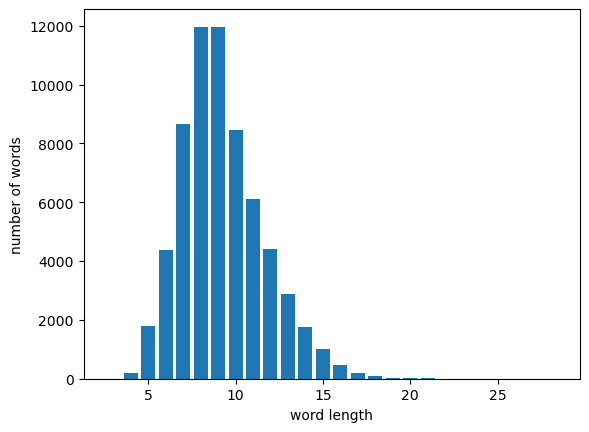

In [28]:
import matplotlib.pyplot as plt

counts = Counter(map(len, words)) # Counter of word lengths
plt.bar(list(counts.keys()), list(counts.values()))
plt.xlabel('word length'); plt.ylabel('number of words');

**Question: What is the longest word?** 

In [29]:
max(W, key=len)

'antidisestablishmentarianism'

**Question: What is the distribution of letters in the Wordset?**

In [30]:
Counter(L for w in words for L in w).most_common() # Counter of letters

[('e', 68038),
 ('s', 60080),
 ('i', 53340),
 ('a', 43177),
 ('n', 42145),
 ('r', 41794),
 ('t', 38093),
 ('o', 35027),
 ('l', 32356),
 ('c', 23100),
 ('d', 22448),
 ('u', 19898),
 ('g', 17815),
 ('p', 16128),
 ('m', 16062),
 ('h', 12673),
 ('y', 11889),
 ('b', 11581),
 ('f', 7885),
 ('v', 5982),
 ('k', 4892),
 ('w', 4880),
 ('z', 2703),
 ('x', 1677),
 ('j', 1076),
 ('q', 1066)]

**Question: How many bridges are there?** 

In [31]:
# Make a list of all bridges, B
B = sorted(W.bridges[suf][pre] for suf in W.bridges for pre in W.bridges[suf])
len(B)

70300

The ones with the most excess:

In [32]:
B[-10:] # Sample every 2000th bridge

[Bridge(excess=5, steps=[Step(overlap=1, word='yogi'), Step(overlap=1, word='iraq')]),
 Bridge(excess=5, steps=[Step(overlap=1, word='zinc'), Step(overlap=1, word='conj')]),
 Bridge(excess=5, steps=[Step(overlap=1, word='zuni'), Step(overlap=1, word='iraq')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='bocci'), Step(overlap=1, word='iraq')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='genii'), Step(overlap=1, word='iraq')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='jinni'), Step(overlap=1, word='iraq')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='orc'), Step(overlap=1, word='colloq')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='vouch'), Step(overlap=1, word='hadj')]),
 Bridge(excess=6, steps=[Step(overlap=1, word='xebec'), Step(overlap=1, word='conj')]),
 Bridge(excess=8, steps=[Step(overlap=1, word='xebec'), Step(overlap=1, word='colloq')])]

Every 4000th bridge:

In [33]:
B[::4000]

[Bridge(excess=0, steps=[Step(overlap=1, word='aahed')]),
 Bridge(excess=0, steps=[Step(overlap=1, word='groin')]),
 Bridge(excess=0, steps=[Step(overlap=1, word='quiver')]),
 Bridge(excess=0, steps=[Step(overlap=2, word='avast')]),
 Bridge(excess=0, steps=[Step(overlap=2, word='hover')]),
 Bridge(excess=0, steps=[Step(overlap=2, word='rucks')]),
 Bridge(excess=0, steps=[Step(overlap=3, word='bored')]),
 Bridge(excess=0, steps=[Step(overlap=3, word='keltic')]),
 Bridge(excess=0, steps=[Step(overlap=3, word='spats')]),
 Bridge(excess=0, steps=[Step(overlap=4, word='earns')]),
 Bridge(excess=0, steps=[Step(overlap=4, word='sable')]),
 Bridge(excess=1, steps=[Step(overlap=1, word='biped')]),
 Bridge(excess=1, steps=[Step(overlap=1, word='naiad')]),
 Bridge(excess=1, steps=[Step(overlap=2, word='cairo')]),
 Bridge(excess=1, steps=[Step(overlap=2, word='ritzy')]),
 Bridge(excess=1, steps=[Step(overlap=3, word='howdah')]),
 Bridge(excess=1, steps=[Step(overlap=4, word='kazoos')]),
 Bridge(ex

**Question: How many excess letters do the bridges have?** 

In [34]:
# Counter of bridge excess letters
BC = Counter(b.excess for b in B)
BC

Counter({0: 43411, 1: 21306, 2: 4869, 3: 634, 4: 52, 5: 21, 6: 6, 8: 1})

Most of the bridges have 0 or 1 excess letter, so we're doing pretty well. The mean is under 1/2 letter:

In [35]:
from statistics import mean

mean(BC.elements())

0.47372688477951636

**Question: How many 1-step and 2-step bridges are there?**

In [36]:
Counter(len(b.steps) for b in B)

Counter({1: 70155, 2: 145})

There are only 145 2-step bridges; we might as well see them all:

In [37]:
for A, B in letter_pairs:
    bridge = W.bridges[A][B]
    steps = bridge.steps
    if len(steps) == 2:
        w0, w1 = steps[0].word, steps[1].word
        excess = w0[1:] + w1[steps[1].overlap:-1]
        print(f'{A}-{B}: {w0:6} + {w1:6} excess {bridge.excess}: {excess}')

a-f: ago    + of     excess 2: go
a-g: at     + tug    excess 2: tu
a-j: arc    + conj   excess 4: rcon
a-q: air    + iraq   excess 3: ira
a-v: at     + tv     excess 1: t
b-c: bar    + arc    excess 2: ar
b-j: bacon  + conj   excess 4: acon
b-q: bocci  + iraq   excess 6: occira
b-v: bot    + tv     excess 2: ot
c-v: cat    + tv     excess 2: at
d-f: do     + of     excess 1: o
d-j: deco   + conj   excess 4: econ
d-q: deair  + iraq   excess 5: eaira
d-r: do     + or     excess 1: o
d-u: die    + emu    excess 3: iem
d-v: dot    + tv     excess 2: ot
d-z: do     + oyez   excess 3: oye
e-j: econ   + conj   excess 3: con
e-p: eye    + yep    excess 2: ye
e-q: emir   + iraq   excess 4: mira
e-v: eat    + tv     excess 2: at
e-w: era    + raw    excess 2: ra
e-z: elf    + fez    excess 3: lfe
f-c: for    + orc    excess 2: or
f-j: fish   + hadj   excess 5: ishad
f-q: fir    + iraq   excess 3: ira
f-v: fat    + tv     excess 2: at
g-c: go     + orc    excess 2: or
g-f: go     + of     excess

**Question: What strange letter combinations are there?** Let's look at two-letter suffixes or prefixes that only appear in one or two nonsubwords. 

In [38]:
startswith = multimap((w[:2], w) for w in words)

{pre: startswith[pre] # Rare two-letter suffixes
 for pre in startswith if len(startswith[pre]) <= 2}

{'ll': {'llamas', 'llanos'},
 'qa': {'qaids', 'qatar'},
 'qo': {'qophs'},
 'wu': {'wurzel'},
 'uf': {'ufos'},
 'kw': {'kwachas', 'kwashiorkor'},
 'ik': {'ikebanas', 'ikons'},
 'jn': {'jnanas'},
 'zl': {'zlotys'},
 'iv': {'ivories', 'ivory'},
 'hd': {'hdqrs'},
 'tc': {'tchaikovsky'},
 'ip': {'ipecacs'},
 'zw': {'zwiebacks'},
 'xi': {'xiphoids', 'xiphosuran'},
 'bw': {'bwanas'},
 'yc': {'ycleped', 'yclept'},
 'ek': {'ekistics'},
 'ay': {'ayahs', 'ayatollahs'},
 'fj': {'fjords'},
 'gw': {'gweducks', 'gweducs'},
 'aj': {'ajar'},
 'gj': {'gjetosts'},
 'dn': {'dnieper'},
 'ie': {'ieee'},
 'mc': {'mcdonald'},
 'if': {'iffiness'},
 'ee': {'eelgrasses', 'eelworm'},
 'dv': {'dvorak'},
 'ez': {'ezekiel'},
 'pf': {'pfennigs'},
 'ym': {'ymca'},
 'sf': {'sforzatos'},
 'oj': {'ojibwas'},
 'xm': {'xmases'},
 'ct': {'ctrl'},
 'fb': {'fbi'}}

The two-letter prefixes definitely include some strange words!

In [39]:
endswith = multimap((w[-2:], w) for w in words)

{suf: endswith[suf] # Rare two-letter suffixes
 for suf in endswith if len(endswith[suf]) <= 2}

{'hn': {'mendelssohn'},
 'uc': {'caoutchouc'},
 'ko': {'gingko', 'stinko'},
 'ln': {'lincoln'},
 'tu': {'impromptu'},
 'vo': {'concavo'},
 'nx': {'bronx', 'meninx'},
 'gn': {'champaign'},
 'mt': {'daydreamt', 'undreamt'},
 'ec': {'filespec', 'quebec'},
 'xe': {'deluxe', 'maxixe'},
 'oi': {'hanoi', 'polloi'},
 'xo': {'convexo'},
 'we': {'zimbabwe'},
 'pa': {'tampa'},
 'ud': {'aloud', 'overproud'},
 'bm': {'ibm', 'icbm'},
 'lu': {'honolulu'},
 'su': {'shiatsu'},
 'zm': {'transcendentalizm'},
 'ui': {'maqui', 'prosequi'},
 'dt': {'rembrandt'},
 'ao': {'chiao', 'ciao'},
 'xs': {'duplexs'},
 'ji': {'fiji'},
 'ru': {'nehru'},
 'rf': {'waldorf', 'windsurf'},
 'tl': {'peyotl', 'shtetl'},
 'hm': {'microhm'},
 'nu': {'vishnu'},
 'ou': {'thankyou'},
 'dn': {'haydn'},
 'mp': {'prestamp'},
 'ug': {'bedrug', 'sparkplug'},
 'lm': {'stockholm', 'unhelm'},
 'oe': {'monroe'},
 'ep': {'asleep', 'shlep'},
 'ku': {'haiku'},
 'nc': {'dezinc', 'quidnunc'},
 'ai': {'bonsai'},
 'sr': {'ussr'},
 'aa': {'markkaa

The list of two-letter suffixes is mostly picking out proper names and pointing out flaws in the word list. For example, lots of words end in `ab`: blab, cab, crab, dab, gab, jab, lab, boabab, kebab, taxicab, backstab, etc. But must of them are subwords of plural forms; only `skylab` made it into the word list in singular form but not plural.

# Further Work

Here are some things you could do to make the portmantouts more interesting:

- Use linguistic resources (such as [pretrained word embeddings](https://nlp.stanford.edu/projects/glove/)) to teach your program what words are related to each other. Encourage the program to place  related words next to each other. Maybe even make grammatical sentences.
- Use linguistic resources (such as [NLTK](https://github.com/nltk/)) to teach your program where syllable breaks are in words, and what each syllable sounds like. Encourage the program to make overlaps match syllables. (That's why "preferendumdums" sounds better than "fortyphonshore".)

Here are some things you could do to make the portmantouts shorter:

- **Lookahead**: Unused words are chosen based on the degree of overlap, but nothing else. It might help to prefer unused words which have a suffix that matches the prefix of another unused word. A single-word lookahead or a beam search could be used.
- **Word choice ordering**: Perhaps `startswith_table` could sort the words in each key's bucket so that the "difficult" words (say, the ones that end in unusual letters) are encountered earlier in the program's execution, when there are more available words for them to connect to.
- **Expected excess**: The greedy approach minimizes the number of excess letters for each step. But some words are harder to place than others. Instead of just minimizing the excess, consider also the *expected* excess of each word, which could be learned. 
  
Here are some things you could do to make the program more robust:

- Write and run unit tests.
- Find other word lists, perhaps in other languages, and try the program on them.
- Try word lists such as a list of names, or cities or countries, augmented with common short words.
- Consider what to do for a wordset that has missing bridges. You could try three-word bridges, you could allow the program to back up and remove a previously-placed word; you could allow the addition of words to the start as well as the end of `P`.